In [ ]:
import sys
!{sys.executable} -m pip install momentfm
import sys, os
sys.path.append(os.path.abspath(".."))  # go one level upimport numpy as np

import pandas as pd
import matplotlib.pyplot as plt
import torch
import numpy as np
import os
import logging
from pathlib import Path
from momentfm import MOMENTPipeline
import scipy
from sklearn.decomposition import PCA
from moment import load_mean_activations
#from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV #, MultiTaskLassoCV
#from celer import MultiTaskLassoCV
#from sklearn.metrics import mean_squared_error, r2_score

from clustering.moment import  get_activations_MOMENT
from clustering.utils import load_dataset
#from hough_scripts.separability import embeddings_pca_corr, lda_pca_embeddings, embeddings_umap


/home/ekaczmarczyk/anaconda3/envs/reps-tsfm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ekaczmarczyk/anaconda3/envs/reps-tsfm/lib/python3.10/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(
/home/ekaczmarczyk/anaconda3/envs/reps-tsfm/lib/python3.10/site-packages/transformers/utils/generic.py:311: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


In [ ]:

# Shape will be: (n_transform, num_samples, dimension)

num_samples=50
model_type="moment"
output_dir="results"
device="cpu"
n_transform=10

#path = "/zfsauton2/home/ekaczmar/representations-in-tsfms-main/representations-in-tsfms-main/clustering/datasets_clusters/"
path = "/mnt/c/Users/emika/OneDrive/Pulpit/Studia 4. rok/RISS//representations-in-tsfms-main/representations-in-tsfms-main/clustering/datasets_clusters/"
path_save = "/mnt/c/Users/emika/OneDrive/Pulpit/Studia 4. rok/RISS//representations-in-tsfms-main/representations-in-tsfms-main/clustering/activations/"


activations_trends = np.stack([
    load_mean_activations(os.path.join(path, f"trends{ind+1}.parquet"), model_type, num_samples, device)
    for ind in range(n_transform)
])
np.save(os.path.join(path_save,'activations_trends.npy'), activations_trends)

'''activations_sines = np.stack([
    load_mean_activations(os.path.join(path, f"sines{ind+1}.parquet"), model_type, num_samples, device)
    for ind in range(n_transform)
])

np.save(os.path.join(path_save,'activations_sines.npy'), activations_sines)

activations_exps = np.stack([
    load_mean_activations(os.path.join(path, f"exps{ind+1}.parquet"), model_type, num_samples, device)
    for ind in range(n_transform)
])

print(f"Shape: {activations_sines.shape}") # Should show (n_transform, num_samples, dim)
print(f"Type: {type(activations_sines)}")

np.save(os.path.join(path_save,'activations_exps.npy'), activations_exps)

activations_exps = np.stack([
    load_mean_activations(os.path.join(path, f"exp_dense{ind+1}.parquet"), model_type, num_samples, device)
    for ind in range(n_transform)
])

np.save(os.path.join(path_save,'activations_exps_dense.npy'), activations_exps)'''

'activations_sines = np.stack([\n    load_activations(os.path.join(path, f"sines{ind+1}.parquet"), model_type, num_samples, device)\n    for ind in range(n_transform)\n])\n\nnp.save(os.path.join(path_save,\'activations_sines.npy\'), activations_sines)\n\nactivations_exps = np.stack([\n    load_activations(os.path.join(path, f"exps{ind+1}.parquet"), model_type, num_samples, device)\n    for ind in range(n_transform)\n])\n\nprint(f"Shape: {activations_sines.shape}") # Should show (n_transform, num_samples, dim)\nprint(f"Type: {type(activations_sines)}")\n\nnp.save(os.path.join(path_save,\'activations_exps.npy\'), activations_exps)\n\nactivations_exps = np.stack([\n    load_activations(os.path.join(path, f"exp_dense{ind+1}.parquet"), model_type, num_samples, device)\n    for ind in range(n_transform)\n])\n\nnp.save(os.path.join(path_save,\'activations_exps_dense.npy\'), activations_exps)'

In [14]:
activations_exps = np.load(os.path.join(path_save,'activations_trends.npy'))

In [14]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
#import umap.umap_ as umap

n_components = [5]#,5,10,50,100]
n_transform = 10

for n_c in n_components:

    for activations in [activations_trends]:#[activations_trends, activations_sines, activations_exps]:
        combined = activations.reshape(-1, activations.shape[-1])
        reducer = PCA(n_components=n_c)
        #reducer = umap.UMAP( n_components=15,n_neighbors=10,min_dist=0.0,metric="euclidean",random_state=42)

        combined_reduced = reducer.fit_transform(combined)
        n = num_samples
        reduced_list = []
        
        for i in range(n_transform):
            reduced_list.append(combined_reduced[n*i:n*(i+1)])
        print(reduced_list[0].shape)
        X = np.vstack(reduced_list)
        n = reduced_list[0].shape[0]
        l = []
        for i in range(n_transform):
            l += [i] * n
        y = np.array(l)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )

        knn = KNeighborsClassifier(n_neighbors=3)
        knn.fit(X_train, y_train)

        y_pred = knn.predict(X_test)

        print("n_components:" + str(n_c))
        print("Accuracy:", accuracy_score(y_test, y_pred))
        print("\nClassification Report:\n", classification_report(y_test, y_pred))
        print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



(50, 5)
n_components:5
Accuracy: 0.85

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        10
           6       1.00      1.00      1.00        10
           7       0.40      1.00      0.57        10
           8       1.00      0.20      0.33        10
           9       1.00      0.30      0.46        10

    accuracy                           0.85       100
   macro avg       0.94      0.85      0.84       100
weighted avg       0.94      0.85      0.84       100


Confusion Matrix:
 [[10  0  0  0  0  0  0  0  0  0]
 [ 0 10  0  0  0  0  0  0  0  0]
 [ 0  0 10  0  0  0  0  0  0  0]
 [ 0  0  0 10  0  0  0  0  0  0]
 [ 0  0  0  0 10  0  0  0 

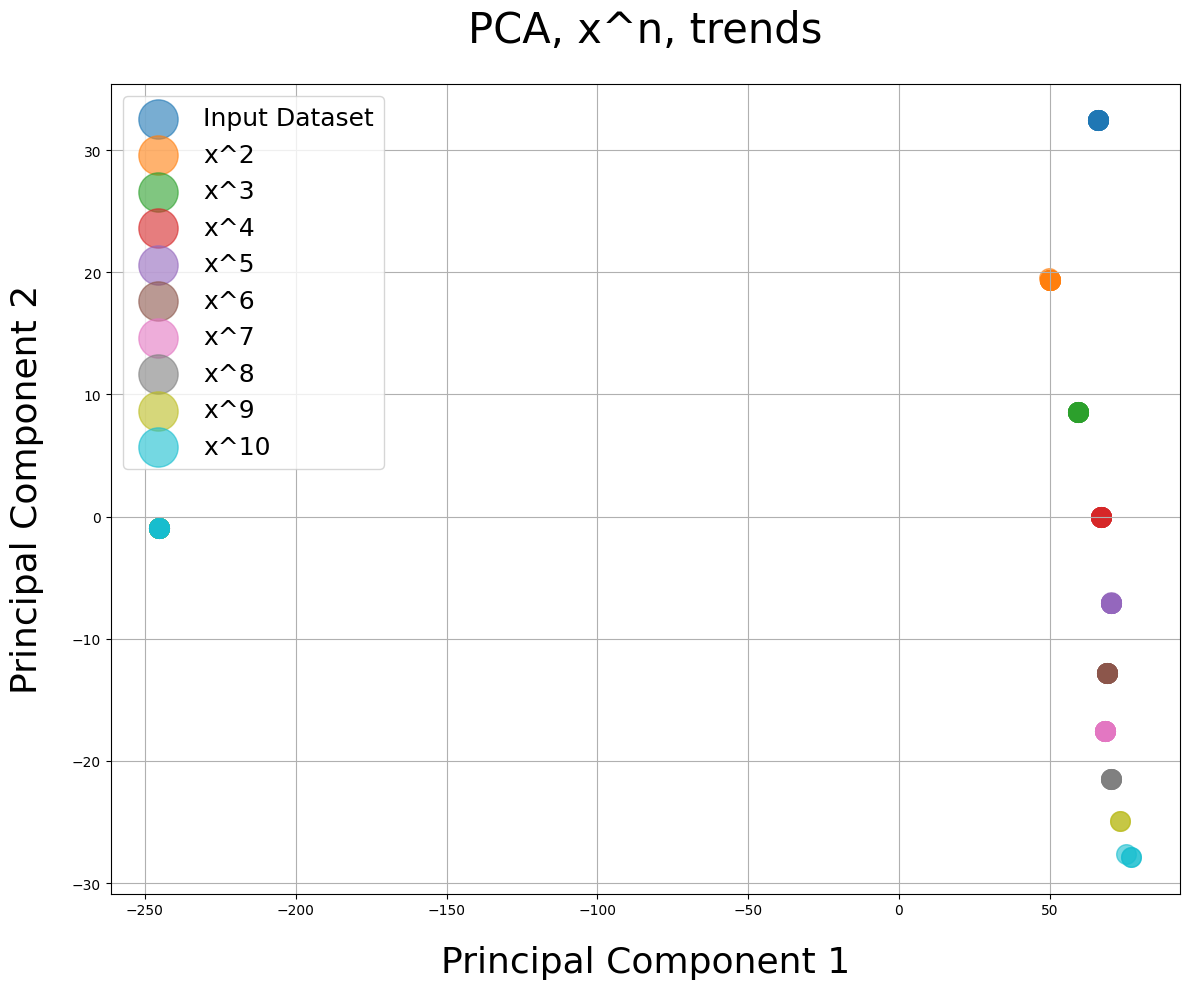

In [15]:
results_list = []

# Filter X_test using the true labels in y_test
for i in range(n_transform):
    # This creates a boolean mask where y_test matches the class index i
    class_mask = (y_test == i)
    results_list.append(X_test[class_mask])

# Now results_list contains only the points belonging to each specific class


fig, ax = plt.subplots(figsize=(12, 10))

colors = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']


# Labels for the legend
labels = ["Input Dataset", "x^2", "x^3", "x^4", "x^5", "x^6", "x^7", "x^8", "x^9", "x^10"]

# Corrected zip order: (data_array, color_string, label_string)
for reduced, color, label in zip(results_list, colors, labels):
    ax.scatter(reduced[:, 0], reduced[:, 1], c=color, label=label, alpha=0.6, s=200)

# Set titles and labels
ax.set_title("PCA, x^n, trends", fontsize=30, pad=30)
ax.set_xlabel("Principal Component 1", fontsize=26, labelpad=20)
ax.set_ylabel("Principal Component 2", fontsize=26, labelpad=20)

# The legend will now work because 'label' was passed to scatter
ax.legend(loc="best", fontsize=18, markerscale=2) 
ax.grid(True)

plt.tight_layout()
plt.show()

Results for 19 classes (Powers 1.0 to 10.0)
KNN Accuracy (5 components): 1.0000


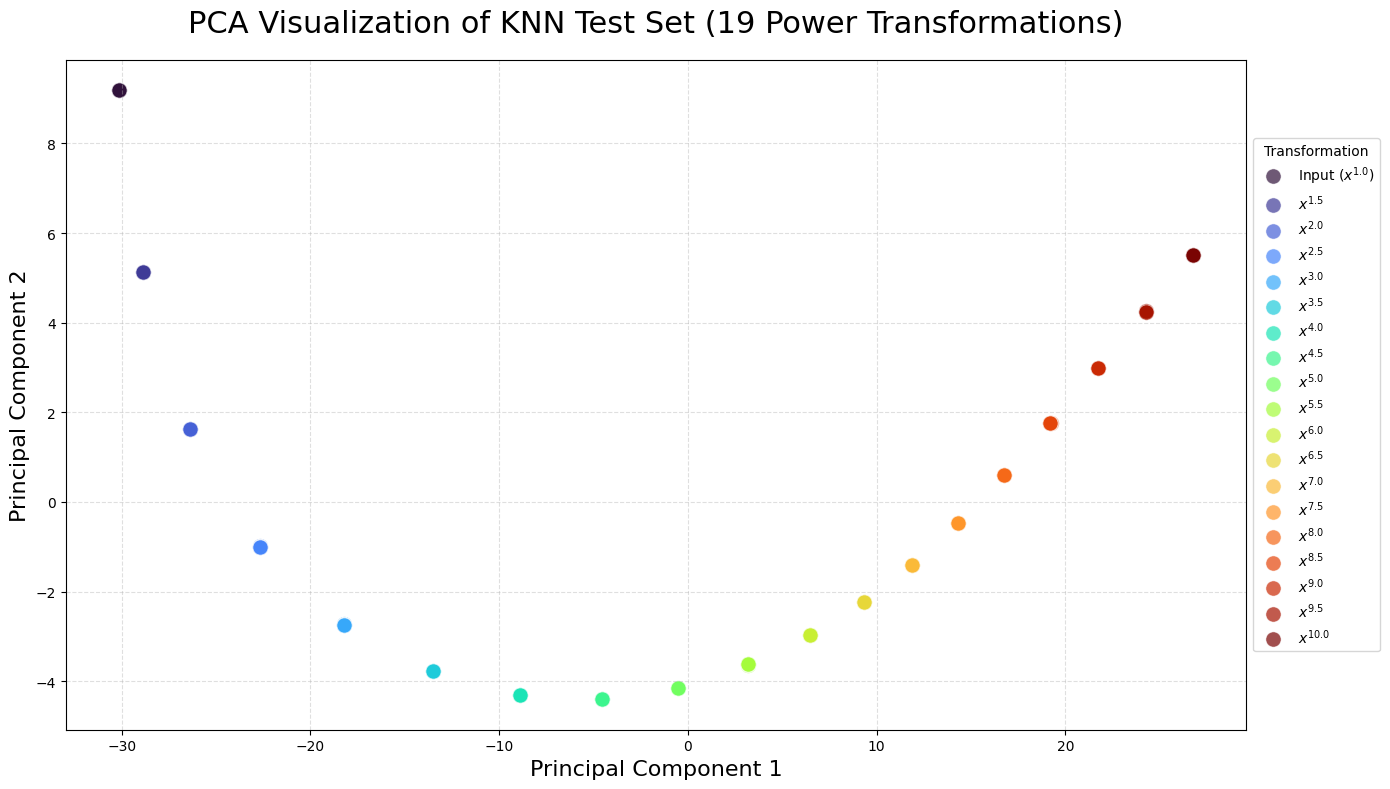

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# 1. Setup Parameters
n_c = 5  # PCA dimensions for KNN training
powers = np.arange(1, 10.5, 0.5) # [1.0, 1.5, ..., 10.0]
n_transform = len(powers)
num_samples = activations_exps.shape[1] # Automatically detect samples per class

# 2. Data Preparation
# Flatten (19, Samples, Dim) -> (19*Samples, Dim)
X_full = activations_exps.reshape(-1, activations_exps.shape[-1])
# Create labels: 0 for first power, 1 for second, etc.
y = np.repeat(np.arange(n_transform), num_samples)

# 3. Dimensionality Reduction
reducer = PCA(n_components=n_c)
X_pca = reducer.fit_transform(X_full)

# 4. Train/Test Split (stratified ensures even distribution of 19 classes)
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# 5. KNN Classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Print Results
print(f"Results for {n_transform} classes (Powers 1.0 to 10.0)")
print(f"KNN Accuracy ({n_c} components): {accuracy_score(y_test, y_pred):.4f}")

# 6. Visualization Preparation
# Slice the 5D test set down to 2D for the plot
X_test_2d = X_test[:, :2] 

# Filter X_test using the TRUE labels (y_test) to create separate groups for the scatter
results_list = [X_test_2d[y_test == i] for i in range(n_transform)]

# Generate automated labels and 19 distinct colors
labels = [f"$x^{{{p:.1f}}}$" for p in powers]
labels[0] = "Input ($x^{1.0}$)"
colors = plt.cm.turbo(np.linspace(0, 1, n_transform)) # 'turbo' is great for 19 gradients

# 7. Plotting
fig, ax = plt.subplots(figsize=(14, 8))

for reduced, color, label in zip(results_list, colors, labels):
    ax.scatter(reduced[:, 0], reduced[:, 1], 
               color=color, label=label, alpha=0.7, s=120, edgecolors='white', linewidth=0.5)

# Styling
ax.set_title(f"PCA Visualization of KNN Test Set ({n_transform} Power Transformations)", fontsize=22, pad=20)
ax.set_xlabel("Principal Component 1", fontsize=16)
ax.set_ylabel("Principal Component 2", fontsize=16)

# Move legend outside because 19 classes take up a lot of vertical space
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), title="Transformation", fontsize=10, ncol=1)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

Results for 10 classes (Powers 1.0 to 10.0)
KNN Accuracy (5 components): 0.7950


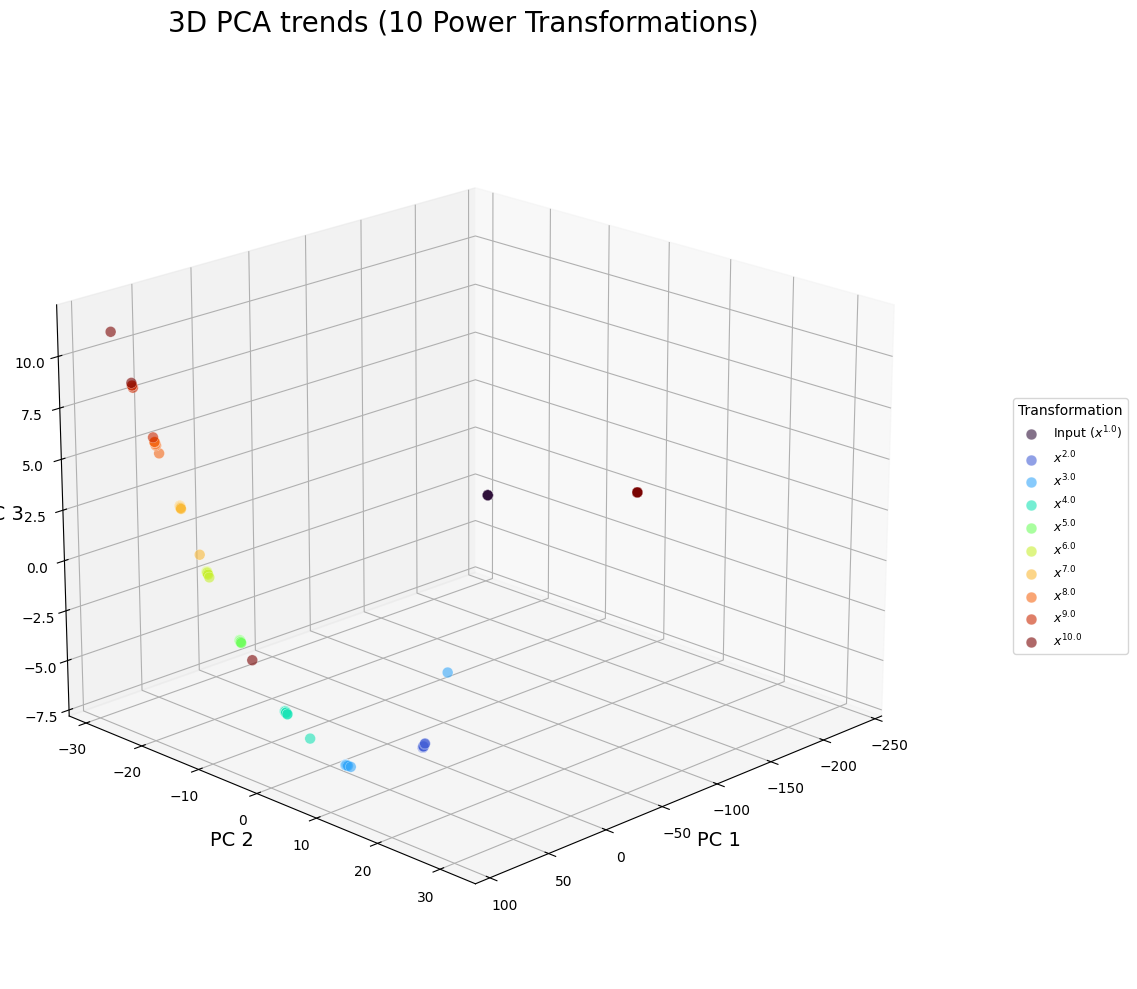

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from mpl_toolkits.mplot3d import Axes3D # Required for 3D projection

# 1. Setup Parameters
n_c = 5  # PCA dimensions for KNN training
#powers = np.arange(1, 10.5, 0.5) 
powers = np.arange(1, 11, 1)
n_transform = len(powers)
num_samples = activations_exps.shape[1] 

# 2. Data Preparation
X_full = activations_exps.reshape(-1, activations_exps.shape[-1])
y = np.repeat(np.arange(n_transform), num_samples)

# 3. Dimensionality Reduction
reducer = PCA(n_components=n_c)
X_pca = reducer.fit_transform(X_full)

# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# 5. KNN Classifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"Results for {n_transform} classes (Powers 1.0 to 10.0)")
print(f"KNN Accuracy ({n_c} components): {accuracy_score(y_test, y_pred):.4f}")

# 6. Visualization Preparation (3D)
# Use first 3 components instead of 2
X_test_3d = X_test[:, :3] 
results_list = [X_test_3d[y_test == i] for i in range(n_transform)]

labels = [f"$x^{{{p:.1f}}}$" for p in powers]
labels[0] = "Input ($x^{1.0}$)"
colors = plt.cm.turbo(np.linspace(0, 1, n_transform))

# 7. 3D Plotting
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d') # Create 3D axes

for reduced, color, label in zip(results_list, colors, labels):
    # Scatter requires x, y, and z coordinates
    ax.scatter(reduced[:, 0], reduced[:, 1], reduced[:, 2],
               color=color, label=label, alpha=0.6, s=60, edgecolors='white', linewidth=0.3)

# Styling for 3D
ax.set_title(f"3D PCA trends ({n_transform} Power Transformations)", fontsize=20, pad=30)
ax.set_xlabel("PC 1", fontsize=14)
ax.set_ylabel("PC 2", fontsize=14)
ax.set_zlabel("PC 3", fontsize=14)

# Adjust viewing angle for better perspective
ax.view_init(elev=20, azim=45)

# Legend outside
ax.legend(loc="center left", bbox_to_anchor=(1.1, 0.5), title="Transformation", fontsize=9, ncol=1)

plt.tight_layout()
plt.show()